In [ ]:
!pip install pyLDAvis
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os

# List of your CSV file names (replace with your actual filenames)
csv_files = ["cleaned_filtered_comments (Phase 1).csv",
             "cleaned_filtered_comments (Phase 2).csv",
             "cleaned_filtered_comments (Phase 3).csv",
             "cleaned_filtered_comments (Phase 4).csv"]

# Read and merge all CSV files
df_list = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

# Save the merged file
merged_df.to_csv("merged_data_final_all_phases.csv", index=False)

print("✅ Merged all files into 'merged_data.csv' successfully!")


✅ Merged all files into 'merged_data.csv' successfully!


In [ ]:
# kumbh 2025

import pandas as pd
import nltk
import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.phrases import Phrases, Phraser

# Load cleaned data
file_path = "/content/merged_data_final_all_phases.csv"  # Replace with actual path
df = pd.read_csv(file_path)

# Download required NLTK datasets
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Define stopwords (expanded)
custom_stopwords = set(stopwords.words("english")) | {
    "kumbh", "mela", "prayagraj", "mahakumbh", "allahabad",  # Event-specific words
    "video", "like", "get", "one", "sir", "bhai", "ji", "ho", "u", "ur",  # Generic words
    "har", "har_har", "jai", "jai_ho","har har mahadev","jai maa ganga",
    "hai", "ki", "se", "ko", "ka", "ke", "k", "bhi", "nahi", "nhi", "hu", "h",
    "yeh", "ye", "kya", "hai", "ki", "ke", "ka", "ko", "se", "jo", "ne", "aur",
    "sab", "tum", "wo", "hota", "wala", "hoti", "bhi", "toh", "hi", "ap", "apne", "bhaiya" # Common praise words
}

# Define relevant keywords for urban infrastructure analysis
relevant_keywords = [
    "cleanliness", "hygiene", "garbage", "waste", "toilet", "sewage", "dustbin",'dirty',
    "water", "shortage", "drinking", "pipeline", "leakage","sanitation","ghat","vip", 'special trains',
    'special buses','hygrogen buses', 'green', 'pontoon bridges', 'AI', 'experience',
    "tent", "accommodation", "stay", "facility",
    "road", "congestion", "traffic", "delay", "bus", "train",
    "crowd", "overcrowding", "stampede", "safety", "security","management", "police", "barricades",
    "bus", "train", "auto", "station", "mobility",
    "management", "planning", "government", "policy", "development", 'arrangements',
    "peaceful", "peace", "amazing", 'nice', 'enjoying','lovely','holy','dip','sangam','beautiful','great',
    'bike', 'e-rickshaw','pilgrims','traffic','queue','logistics','medical services', 'health services',
    'signages','infrastructure', 'walk', 'workers','spiritual','religious' ]



# Function for text preprocessing
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'\d+', '', text)  # Remove numbers
    tokens = word_tokenize(text)  # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalnum() and word not in custom_stopwords]

    # Keep only words related to infrastructure, sanitation, traffic, mobility
    filtered_tokens = [word for word in tokens if word in relevant_keywords]
    return filtered_tokens if filtered_tokens else None  # Remove empty results

df["Processed_Text"] = df["translated_comment"].apply(preprocess_text)
df.dropna(subset=["Processed_Text"], inplace=True)  # Drop rows with empty lists


# Build bigram and trigram models
bigram = Phrases(df["Processed_Text"], min_count=10, threshold=10)
trigram = Phrases(bigram[df["Processed_Text"]], threshold=10)

bigram_phraser = Phraser(bigram)
trigram_phraser = Phraser(trigram)

df["Processed_Text"] = df["Processed_Text"].apply(lambda text: bigram_phraser[text])
df["Processed_Text"] = df["Processed_Text"].apply(lambda text: trigram_phraser[text])

# Prepare Data for LDA
dictionary = corpora.Dictionary(df["Processed_Text"])
dictionary.filter_extremes(no_below=3, no_above=0.7)  # Filter rare and common words
corpus = [dictionary.doc2bow(text) for text in df["Processed_Text"]]

# Train LDA Model
lda_model = LdaModel(corpus, num_topics=3, id2word=dictionary, passes=150, random_state=42)

# Display Topics
print("\n🔹 Topics Identified:")
topics = lda_model.print_topics(num_words=8)
for i, topic in topics:
    print(f"Topic {i + 1}: {topic}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



🔹 Topics Identified:
Topic 1: 0.269*"vip" + 0.169*"government" + 0.160*"sangam" + 0.089*"ghat" + 0.065*"train" + 0.063*"crowd" + 0.050*"beautiful" + 0.036*"religious"
Topic 2: 0.266*"nice" + 0.120*"stampede" + 0.089*"station" + 0.080*"amazing" + 0.066*"experience" + 0.057*"road" + 0.055*"stay" + 0.054*"holy"
Topic 3: 0.250*"police" + 0.213*"great" + 0.115*"water" + 0.094*"management" + 0.088*"bus" + 0.046*"tent" + 0.039*"bike" + 0.030*"security"


In [ ]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER (only required once)
nltk.download('vader_lexicon')

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Load your YouTube comments dataset (Replace 'your_file.csv' with your actual filename)
df = pd.read_csv('/content/merged_data_final_all_phases.csv')

# Ensure the comments column is named correctly
comments_col = 'translated_comment'  # Change if your column has a different name
df = df[[comments_col]].dropna()  # Keep only the relevant column and remove NaNs

# Define topics and their keywords based on the refined table
topics = {
    "Mela Management": [ "government", "policy", "development", "hygiene", "police",
                        "facility","holy","peaceful", "lovely","policy","station",
                         "religious","spiritual","auto","infrastructure","development","garbage"],
    "Pilgrimage Experience & Planning": ["experience", "stay", "accommodation", "cleanliness", "walk", "enjoying", "overcrowding",
                                         "great", "management","security","waste","safety","planning","garbage","green",
                                         "sangam","ghat","amazing","toilet","sanitation","sewage","dip","drinking"],

    "Transport & Mobility": [ "stampede", "bus", "crowd", "dirty", "train",
                             "bike","shortage","delay"]

}

# Function to classify comments into topics
def assign_topic(comment):
    for topic, keywords in topics.items():
        if any(keyword in comment.lower() for keyword in keywords):
            return topic
    return "Other"  # If no matching topic is found

# Apply topic classification
df['Topic'] = df[comments_col].apply(assign_topic)

# Apply sentiment analysis
df['Sentiment_Score'] = df[comments_col].apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize into Positive, Neutral, Negative
df['Sentiment_Label'] = df['Sentiment_Score'].apply(lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral"))

# Aggregate sentiment results per topic
sentiment_summary = df.groupby('Topic')['Sentiment_Score'].mean().reset_index()
sentiment_summary.columns = ['Topic', 'Average_Sentiment_Score']
sentiment_summary['Overall_Sentiment'] = sentiment_summary['Average_Sentiment_Score'].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Save results to a CSV file
df.to_csv('youtube_comments_with_sentiments.csv', index=False)
sentiment_summary.to_csv('topic_wise_sentiment_analysis.csv', index=False)

# Display the final sentiment summary
print(sentiment_summary)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                              Topic  Average_Sentiment_Score Overall_Sentiment
0                   Mela Management                 0.092114          Positive
1                             Other                 0.079390          Positive
2  Pilgrimage Experience & Planning                 0.253183          Positive
3              Transport & Mobility                -0.057381          Negative


<ipython-input-15-0b3c792e8406>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary, x='Topic', y='Average_Sentiment_Score', palette='coolwarm')


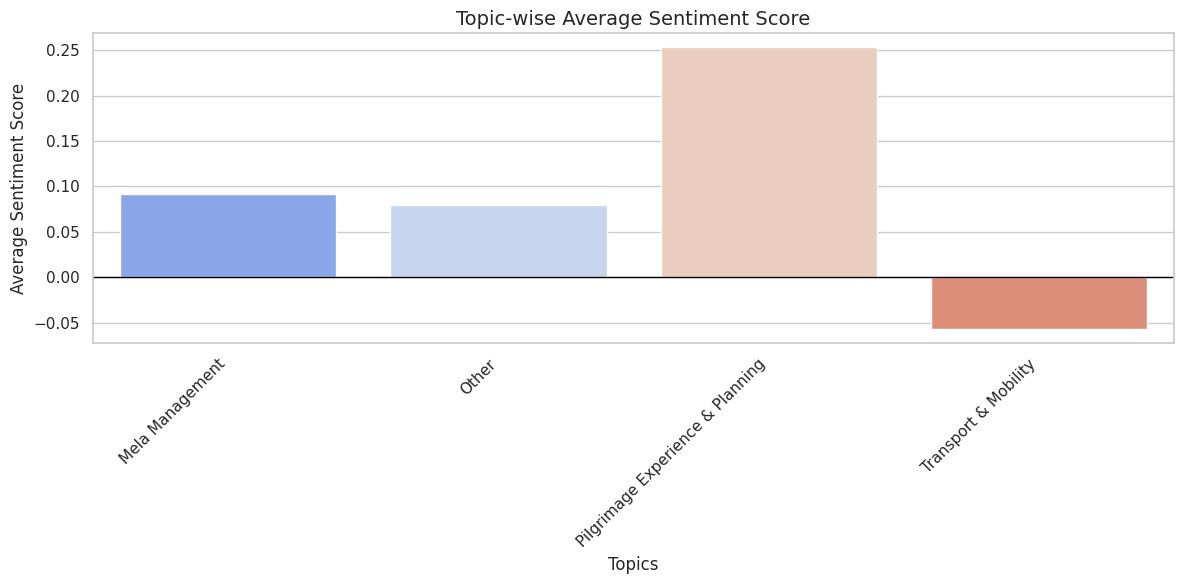

<ipython-input-15-0b3c792e8406>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sentiment_summary, x='Overall_Sentiment', palette='pastel')


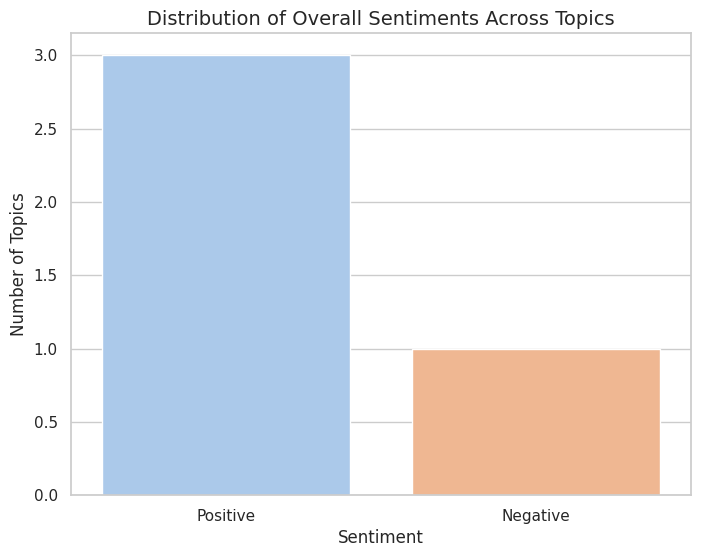

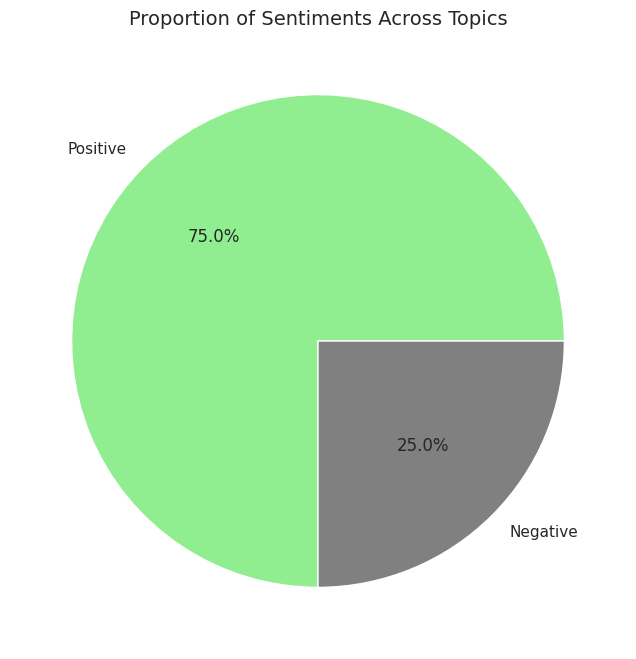

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the sentiment summary dataset
sentiment_summary = pd.read_csv('topic_wise_sentiment_analysis.csv')

# Set up visualization style
sns.set(style="whitegrid")

# Bar Plot: Topic vs. Average Sentiment Score
plt.figure(figsize=(12, 6))
sns.barplot(data=sentiment_summary, x='Topic', y='Average_Sentiment_Score', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title("Topic-wise Average Sentiment Score", fontsize=14)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Average Sentiment Score", fontsize=12)
plt.axhline(0, color='black', linewidth=1)  # Add a reference line at 0
plt.tight_layout()
plt.show()

# Count of Positive, Neutral, and Negative Topics
plt.figure(figsize=(8, 6))
sns.countplot(data=sentiment_summary, x='Overall_Sentiment', palette='pastel')
plt.title("Distribution of Overall Sentiments Across Topics", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Number of Topics", fontsize=12)
plt.show()

# Pie Chart: Sentiment Distribution
plt.figure(figsize=(8, 8))
sentiment_counts = sentiment_summary['Overall_Sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['lightgreen', 'gray', 'lightcoral'])
plt.title("Proportion of Sentiments Across Topics", fontsize=14)
plt.show()


<Figure size 1400x800 with 0 Axes>

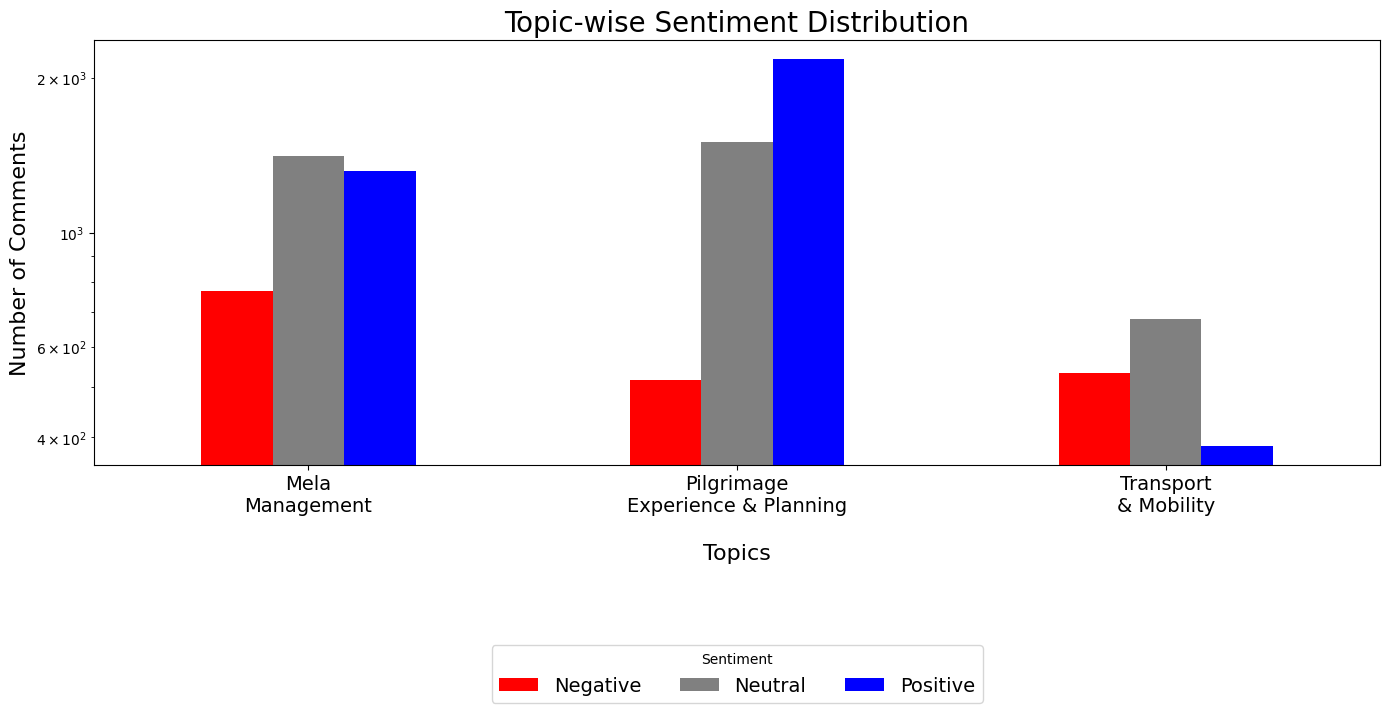

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
df = pd.read_csv('youtube_comments_with_sentiments.csv')

# Count the number of Positive, Neutral, and Negative comments per topic
sentiment_distribution = df.groupby(['Topic', 'Sentiment_Label']).size().unstack(fill_value=0)

# Optional: Remove "Other" category if it's too large
if 'Other' in sentiment_distribution.index:
    sentiment_distribution = sentiment_distribution.drop(index='Other')

# Modify topic names to be in two lines
modified_labels = [label.replace(" ", "\n", 1) for label in sentiment_distribution.index]  # Replaces first space with \n

# Define custom colors for sentiments
custom_colors = {"Negative": "red", "Neutral": "gray", "Positive": "blue"}

# Plotting
plt.figure(figsize=(14, 8))
ax = sentiment_distribution.plot(kind='bar', stacked=False, figsize=(14, 8), color=[custom_colors[col] for col in sentiment_distribution.columns])

# Formatting
plt.title("Topic-wise Sentiment Distribution", fontsize=20)
plt.xlabel("Topics", fontsize=16, labelpad=20)
plt.ylabel("Number of Comments", fontsize=16)
plt.xticks(ticks=range(len(modified_labels)), labels=modified_labels, rotation=0, ha='center', fontsize=14)  # Center-align two-line labels
plt.yscale('log')  # Apply log scale to handle large differences

# Custom Legend
plt.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"], loc='upper center',
           bbox_to_anchor=(0.5, -0.4), ncol=3, fontsize=14)

plt.grid(False)  # Remove grid lines

# Display the plot
plt.tight_layout()
plt.show()


<ipython-input-17-a79f4e7d5abe>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_sentiment, x='Topic', y='Average_Sentiment_Score', palette='coolwarm')


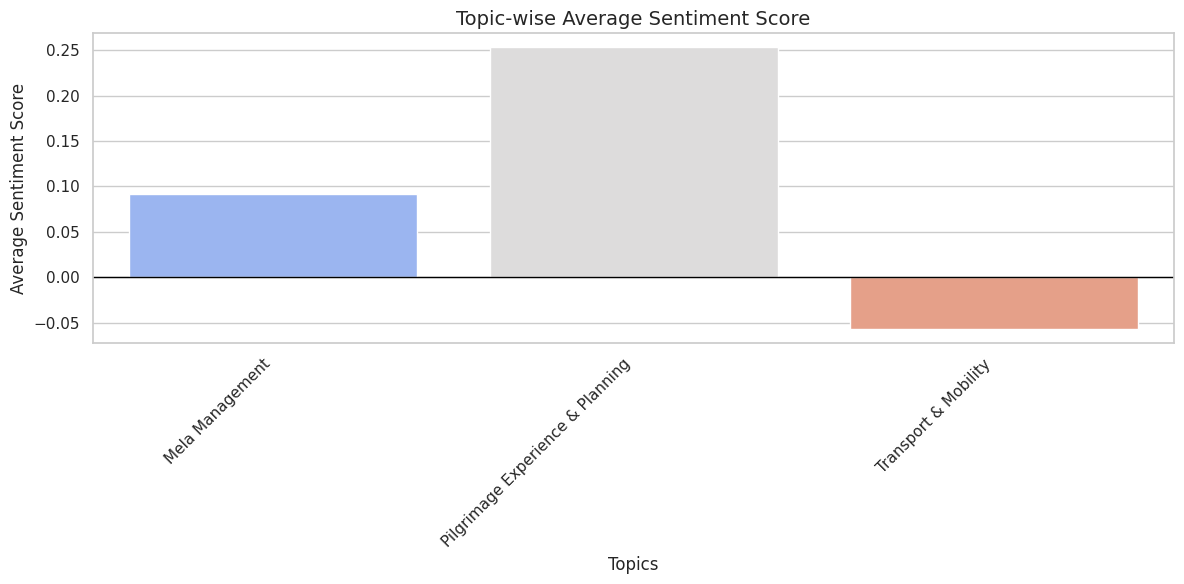

In [ ]:
# Filter out the 'Other' category
filtered_sentiment = sentiment_summary[sentiment_summary['Topic'] != 'Other']

# Bar Plot: Topic vs. Average Sentiment Score (without "Other")
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_sentiment, x='Topic', y='Average_Sentiment_Score', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title("Topic-wise Average Sentiment Score", fontsize=14)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Average Sentiment Score", fontsize=12)
plt.axhline(0, color='black', linewidth=1)  # Add a reference line at 0
plt.tight_layout()
plt.show()


In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Prepare the visualization
lda_vis = gensimvis.prepare(lda_model, corpus, dictionary)

# Display the visualization
pyLDAvis.display(lda_vis)

In [ ]:
import pyLDAvis

pyLDAvis.save_html(lda_vis, "lda_visualization.html")


<ipython-input-3-d7b77cd5cdcb>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=urban_infra_df, x='Topic', y='Average_Sentiment_Score', palette='coolwarm', width = 0.5)


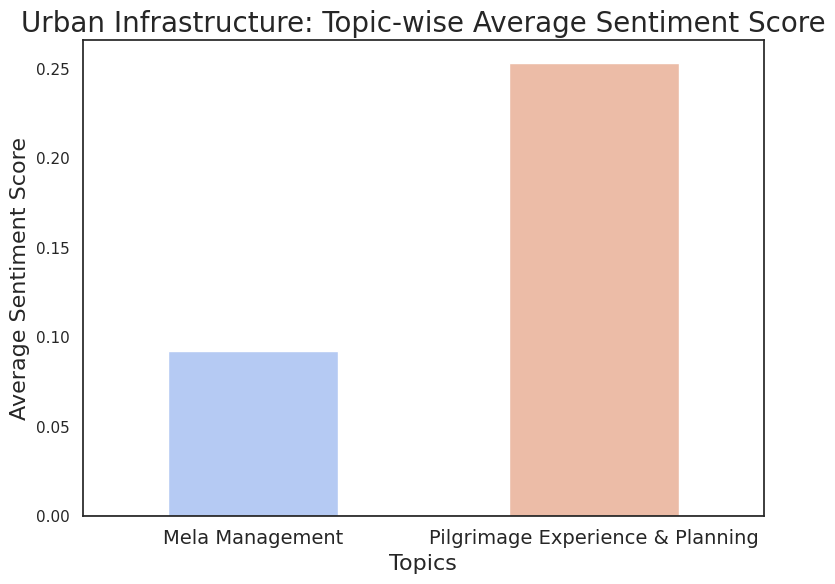

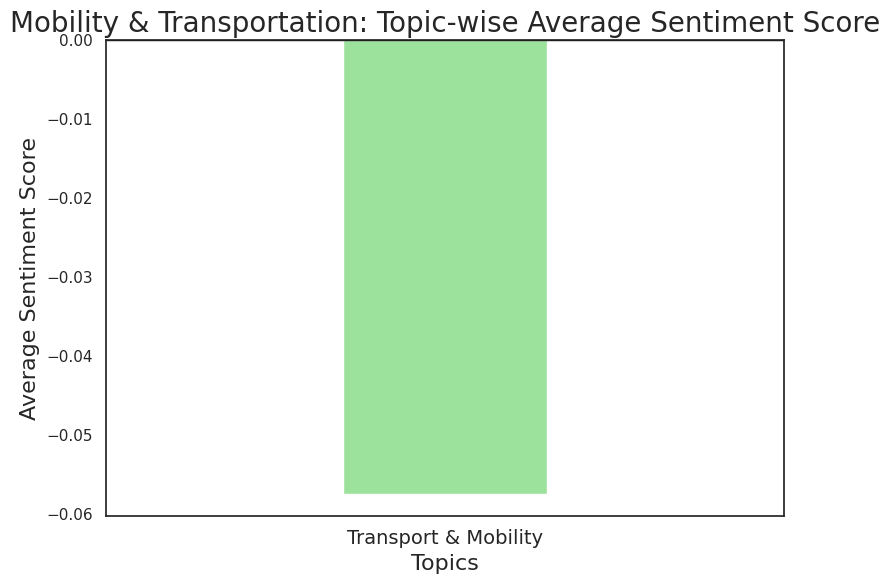

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the sentiment summary dataset
sentiment_summary = pd.read_csv('topic_wise_sentiment_analysis.csv')

# Define topics for each chapter
urban_infrastructure_topics = [
    "Mela Management",
    "Pilgrimage Experience & Planning"
]

mobility_transportation_topics = [
    "Transport & Mobility"
]

# Filter data for each chapter
urban_infra_df = sentiment_summary[sentiment_summary['Topic'].isin(urban_infrastructure_topics)]
mobility_transport_df = sentiment_summary[sentiment_summary['Topic'].isin(mobility_transportation_topics)]

# Set up visualization style
sns.set(style="white")

# Bar Plot: Urban Infrastructure - Topic vs. Average Sentiment Score
plt.figure(figsize=(8, 6))
sns.barplot(data=urban_infra_df, x='Topic', y='Average_Sentiment_Score', palette='coolwarm', width = 0.5)
plt.xticks(rotation=0, ha='center', fontsize = 14)
plt.title("Urban Infrastructure: Topic-wise Average Sentiment Score", fontsize=20)
plt.xlabel("Topics", fontsize=16)
plt.ylabel("Average Sentiment Score", fontsize=16)
plt.axhline(0, color='black', linewidth=1)  # Add a reference line at 0
plt.tight_layout()
plt.show()

# Bar Plot: Mobility & Transportation - Topic vs. Average Sentiment Score
plt.figure(figsize=(8, 6))
sns.barplot(data=mobility_transport_df, x='Topic', y='Average_Sentiment_Score', color='lightgreen', width = 0.3)
plt.xticks(rotation=0, ha='center', fontsize = 14)
plt.title("Mobility & Transportation: Topic-wise Average Sentiment Score", fontsize=20)
plt.xlabel("Topics", fontsize=16)
plt.ylabel("Average Sentiment Score", fontsize=16)
plt.axhline(0, color='black', linewidth=1)  # Add a reference line at 0
plt.tight_layout()
plt.show()


Available Topics: ['Other' 'Mela Management' 'Transport & Mobility'
 'Pilgrimage Experience & Planning']


<Figure size 1200x600 with 0 Axes>

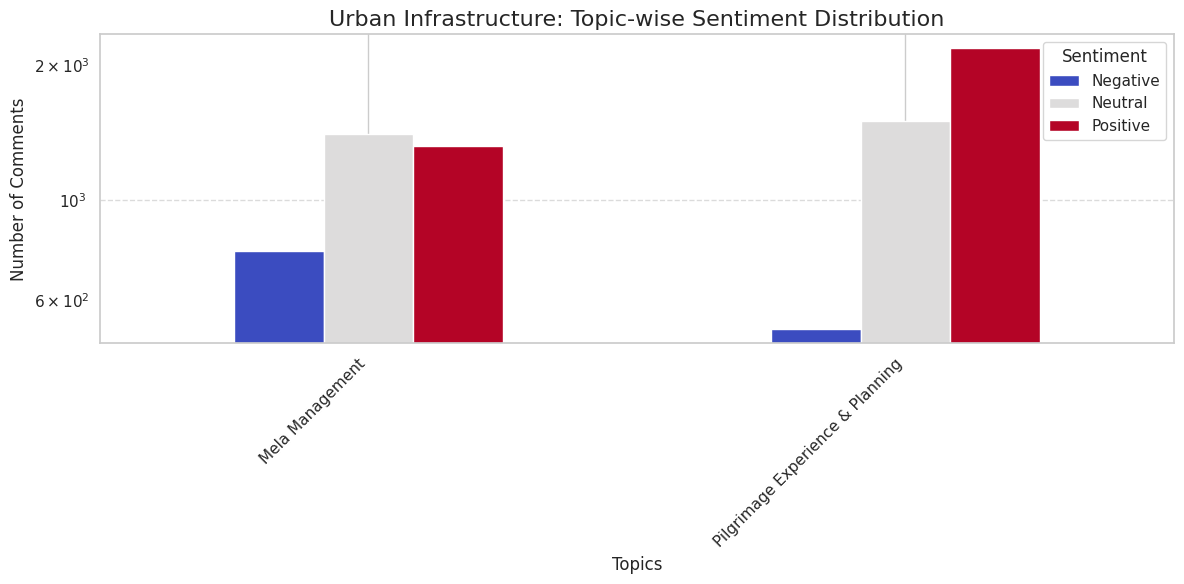

<Figure size 1200x600 with 0 Axes>

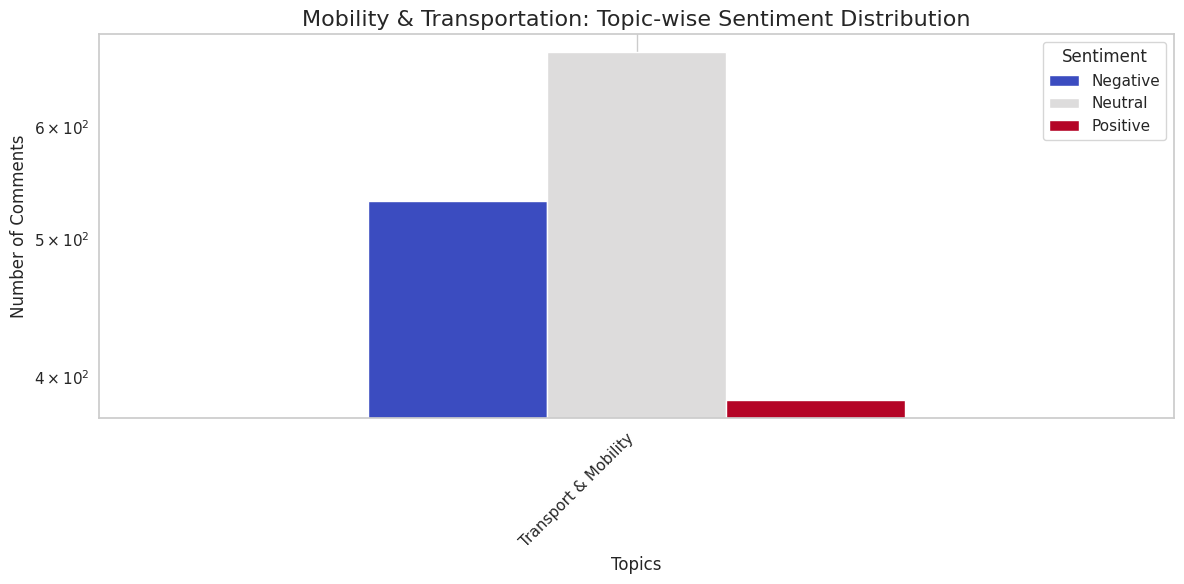

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
df = pd.read_csv('youtube_comments_with_sentiments.csv')

# Print available topics for debugging
print("Available Topics:", df['Topic'].unique())

# Count the number of Positive, Neutral, and Negative comments per topic
sentiment_distribution = df.groupby(['Topic', 'Sentiment_Label']).size().unstack(fill_value=0)

# Define topics for each chapter (after verifying correct names)
urban_infrastructure_topics = [
     "Mela Management",
    "Pilgrimage Experience & Planning"
]

mobility_transportation_topics = [
    "Transport & Mobility"
]

# Filter only existing topics to avoid errors
urban_infra_distribution = sentiment_distribution.loc[
    sentiment_distribution.index.intersection(urban_infrastructure_topics)
]

mobility_transport_distribution = sentiment_distribution.loc[
    sentiment_distribution.index.intersection(mobility_transportation_topics)
]

# Set up visualization style
sns.set(style="whitegrid")

# Urban Infrastructure - Topic-wise Sentiment Distribution
plt.figure(figsize=(12, 6))
urban_infra_distribution.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='coolwarm',width= 0.5)

# Formatting
plt.title("Urban Infrastructure: Topic-wise Sentiment Distribution", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Number of Comments", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yscale('log')  # Apply log scale to handle large differences
plt.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

# Mobility & Transportation - Topic-wise Sentiment Distribution
plt.figure(figsize=(12, 6))
mobility_transport_distribution.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='coolwarm', width = 0.5)

# Formatting
plt.title("Mobility & Transportation: Topic-wise Sentiment Distribution", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Number of Comments", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yscale('log')  # Apply log scale to handle large differences
plt.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


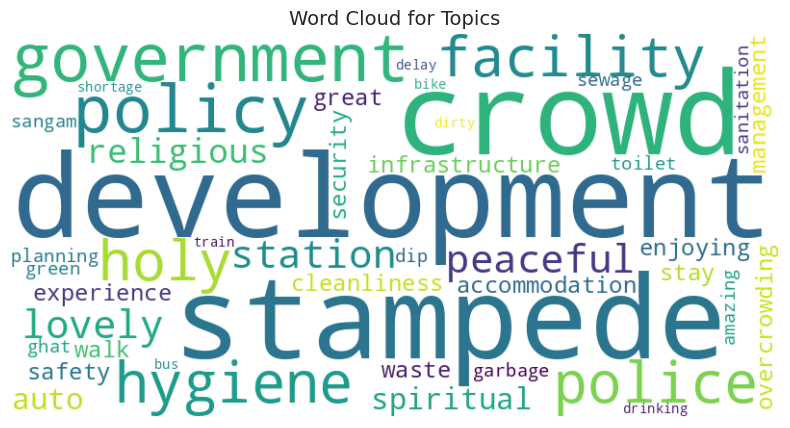

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Define the topics and their associated keywords
topics = {
    "Mela Management": ["government", "policy", "development", "hygiene", "police",
                        "facility", "holy", "peaceful", "lovely", "station",
                        "religious", "spiritual", "auto", "infrastructure", "development"],
    "Pilgrimage Experience & Planning": ["experience", "stay", "accommodation", "cleanliness", "walk", "enjoying", "overcrowding",
                                         "great", "management", "security", "waste", "safety", "planning", "garbage", "green",
                                         "sangam","stampede", "ghat", "amazing", "toilet", "sanitation", "sewage", "dip", "drinking","crowd"],
    "Transport & Mobility": ["stampede", "bus", "crowd", "dirty", "train",
                             "bike", "shortage", "delay"]
}

# Combine all words into a single string
all_words = " ".join([" ".join(words) for words in topics.values()])

# Generate the word cloud without colormap
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.title("Word Cloud for Topics", fontsize=14)
plt.show()


<Figure size 800x600 with 0 Axes>

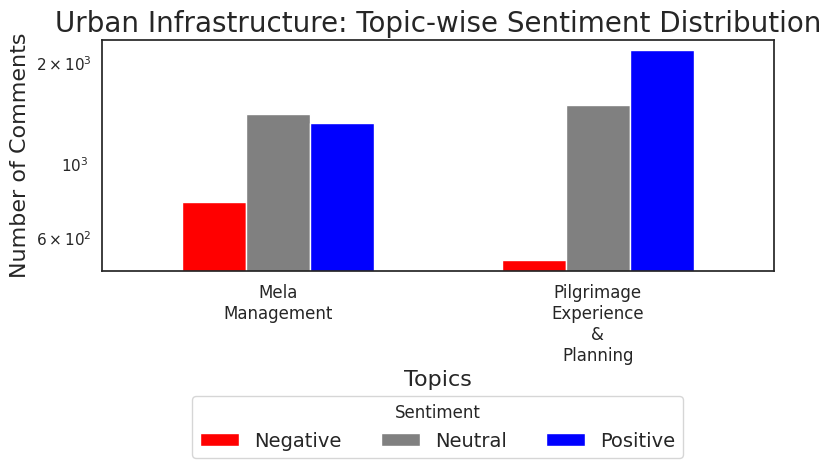

<Figure size 800x600 with 0 Axes>

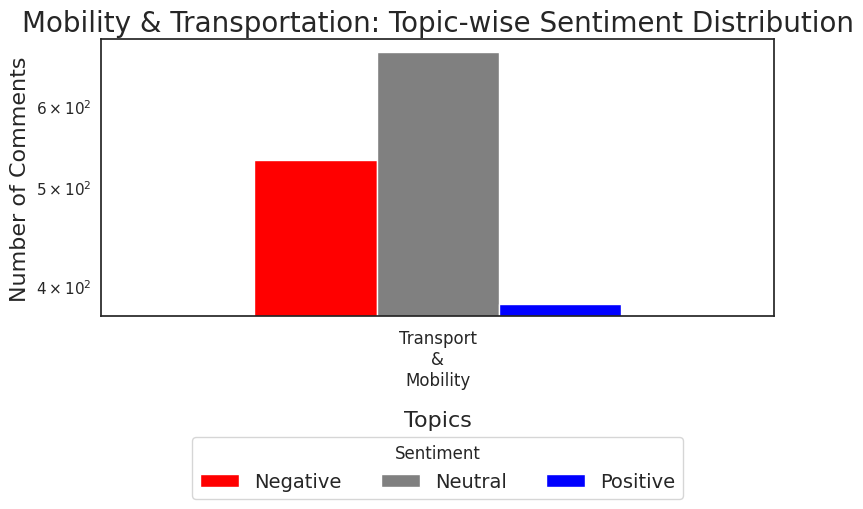

In [ ]:
sns.set(style="white")
# Urban Infrastructure - Topic-wise Sentiment Distribution
plt.figure(figsize=(8, 6))  # Reduced width from 12 to 8
urban_infra_distribution.plot(kind='bar', stacked=False, figsize=(8, 6), color=custom_colors, width=0.6)

# Formatting
plt.title("Urban Infrastructure: Topic-wise Sentiment Distribution", fontsize=20)
plt.xlabel("Topics", fontsize=16)
plt.ylabel("Number of Comments", fontsize=16)
plt.xticks(ticks=range(len(urban_infra_distribution.index)), labels=format_xticks(urban_infra_distribution.index), rotation=0, ha='center', fontsize=12 )
plt.yscale('log')
plt.grid(False)

# Move legend below
plt.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"], loc='upper center',
           bbox_to_anchor=(0.5, -0.5), ncol=3, fontsize=14)  # Adjusted legend placement

plt.tight_layout()
plt.show()

# Mobility & Transportation - Topic-wise Sentiment Distribution
plt.figure(figsize=(8, 6))  # Reduced width from 12 to 8
mobility_transport_distribution.plot(kind='bar', stacked=False, figsize=(8, 6), color=custom_colors, width=0.6)

# Formatting
plt.title("Mobility & Transportation: Topic-wise Sentiment Distribution", fontsize=20)
plt.xlabel("Topics", fontsize=16,labelpad = 15)
plt.ylabel("Number of Comments", fontsize=16)
plt.xticks(ticks=range(len(mobility_transport_distribution.index)), labels=format_xticks(mobility_transport_distribution.index), rotation=0, ha='center', fontsize=12)
plt.yscale('log')
plt.grid(False)

# Move legend below
plt.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"], loc='upper center',
           bbox_to_anchor=(0.5, -0.4), ncol=3, fontsize=14)

plt.tight_layout()
plt.show()


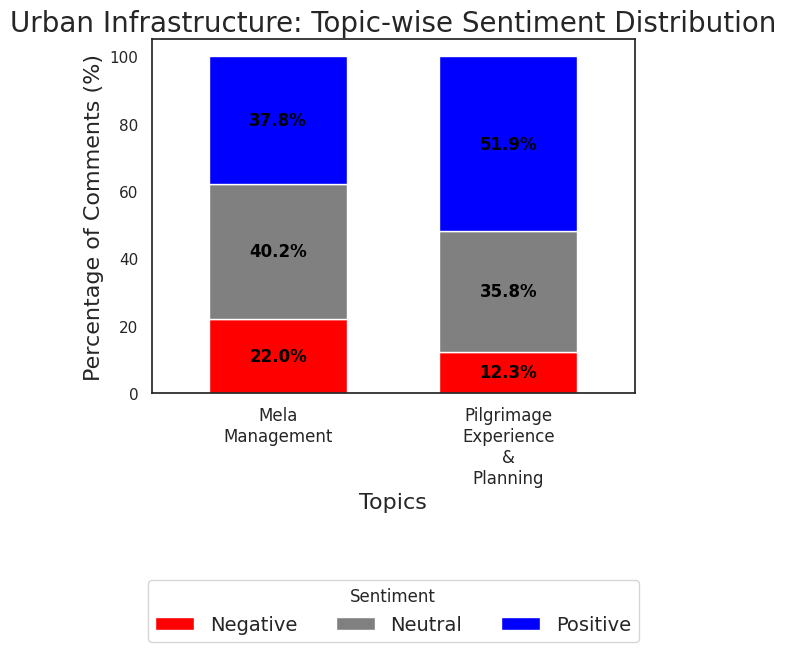

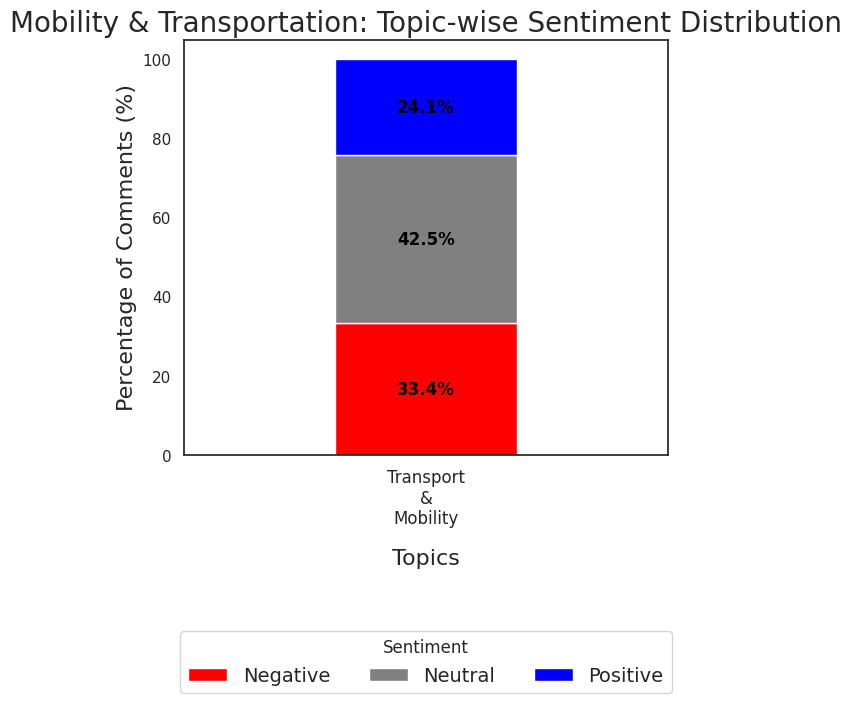

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
df = pd.read_csv('youtube_comments_with_sentiments.csv')

# Count the number of Positive, Neutral, and Negative comments per topic
sentiment_distribution = df.groupby(['Topic', 'Sentiment_Label']).size().unstack(fill_value=0)

# Define topics for each category
urban_infrastructure_topics = ["Mela Management", "Pilgrimage Experience & Planning"]
mobility_transportation_topics = ["Transport & Mobility"]

# Filter only existing topics to avoid errors
urban_infra_distribution = sentiment_distribution.loc[
    sentiment_distribution.index.intersection(urban_infrastructure_topics)
]
mobility_transport_distribution = sentiment_distribution.loc[
    sentiment_distribution.index.intersection(mobility_transportation_topics)
]

# Convert raw counts to percentages
urban_infra_percentage = urban_infra_distribution.div(urban_infra_distribution.sum(axis=1), axis=0) * 100
mobility_transport_percentage = mobility_transport_distribution.div(mobility_transport_distribution.sum(axis=1), axis=0) * 100

# Set up visualization style
sns.set(style="white")

# Define custom colors
custom_colors = ["red", "gray", "blue"]  # Red for Negative, Gray for Neutral, Blue for Positive

# Function to format x-axis labels with line breaks
def format_xticks(labels):
    return [label.replace(" ", "\n") for label in labels]  # Replacing space with newline

# Function to annotate bars with percentages
def add_percentage_labels(ax, data):
    for i, topic in enumerate(data.index):
        cumulative_height = 0
        for sentiment, color in zip(data.columns, custom_colors):
            height = data.loc[topic, sentiment]
            if height > 0:
                ax.text(i, cumulative_height + height / 2, f"{height:.1f}%",
                        ha="center", va="center", fontsize=12, color="black", fontweight="bold")
            cumulative_height += height

# Urban Infrastructure - Topic-wise Sentiment Distribution
fig, ax = plt.subplots(figsize=(6, 8))
urban_infra_percentage.plot(kind='bar', stacked=True, ax=ax, color=custom_colors, width=0.6)

# Formatting
ax.set_title("Urban Infrastructure: Topic-wise Sentiment Distribution", fontsize=20)
ax.set_xlabel("Topics", fontsize=16)
ax.set_ylabel("Percentage of Comments (%)", fontsize=16)
ax.set_xticks(range(len(urban_infra_percentage.index)))
ax.set_xticklabels(format_xticks(urban_infra_percentage.index), rotation=0, ha='center', fontsize=12)
ax.grid(False)

# Add percentage labels
add_percentage_labels(ax, urban_infra_percentage)

# Move legend below
ax.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"], loc='upper center',
          bbox_to_anchor=(0.5, -0.5), ncol=3, fontsize=14)

plt.tight_layout()
plt.show()

# Mobility & Transportation - Topic-wise Sentiment Distribution
fig, ax = plt.subplots(figsize=(6, 8))
mobility_transport_percentage.plot(kind='bar', stacked=True, ax=ax, color=custom_colors, width=0.3)

# Formatting
ax.set_title("Mobility & Transportation: Topic-wise Sentiment Distribution", fontsize=20)
ax.set_xlabel("Topics", fontsize=16, labelpad=15)
ax.set_ylabel("Percentage of Comments (%)", fontsize=16)
ax.set_xticks(range(len(mobility_transport_percentage.index)))
ax.set_xticklabels(format_xticks(mobility_transport_percentage.index), rotation=0, ha='center', fontsize=12)
ax.grid(False)

# Add percentage labels
add_percentage_labels(ax, mobility_transport_percentage)

# Move legend below
ax.legend(title="Sentiment", labels=["Negative", "Neutral", "Positive"], loc='upper center',
          bbox_to_anchor=(0.5, -0.4), ncol=3, fontsize=14)

plt.tight_layout()
plt.show()
